In [71]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [72]:
DATA_PATHS = [
    "online_gaming_behavior_dataset.csv",
    "/mnt/data/online_gaming_behavior_dataset.csv"
]

for p in DATA_PATHS:
    if os.path.exists(p):
        DATA_PATH = p
        break
else:
    raise FileNotFoundError("Dataset not found in expected paths.")

df = pd.read_csv(DATA_PATH)

In [73]:
print("Shape:", df.shape)

df.head(5)

Shape: (40034, 13)


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [74]:
# 1. Class distribution (Low/Medium/High)
# 1.1 Frequency and Proportion

dist = df["EngagementLevel"].value_counts(dropna=False)
prop = df["EngagementLevel"].value_counts(normalize=True, dropna=False)

summary = pd.DataFrame({"count": dist, "proportion": prop})
summary

,count,proportion
EngagementLevel,,
Medium,19374,0.483939
High,10336,0.258181
Low,10324,0.257881


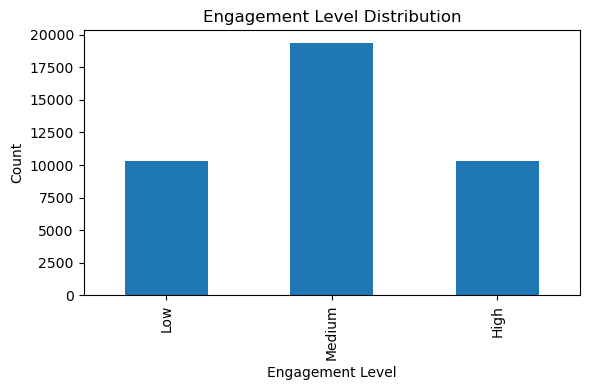

In [75]:
# 1.2 Bar chart
plt.figure(figsize=(6,4))
summary.loc[["Low", "Medium", "High"], "count"].plot(kind="bar")
plt.title("Engagement Level Distribution")
plt.xlabel("Engagement Level")
plt.ylabel("Count")
plt.tight_layout()

The distribution indicates a moderate class imbalance, with low engagement players forming a minority of the population.

In [76]:
# 2. Missing values 
missing_count = df.isna().sum().sort_values(ascending=True)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
})

missing_summary

,missing_count,missing_pct
PlayerID,0,0.0
Age,0,0.0
Gender,0,0.0
Location,0,0.0
GameGenre,0,0.0
PlayTimeHours,0,0.0
InGamePurchases,0,0.0
GameDifficulty,0,0.0
SessionsPerWeek,0,0.0
AvgSessionDurationMinutes,0,0.0


No missing values were detected in the key behavioural and engagement-related features used for EDA.  
The preprocessing pipeline retains imputation steps for reproducibility and robustness in later modelling stages.

In [77]:
# 3. Correlation between features and "EngagementLevel"
# 3.1 Define numeric/categorical lists

candidate_features = [
    "Age",
    "Gender",
    "Location",
    "GameGenre",
    "GameDifficulty",
    "PlayTimeHours",
    "SessionsPerWeek",
    "AvgSessionDurationMinutes",
    "PlayerLevel",
    "AchievementsUnlocked",
    "InGamePurchases"
]

df_eda = df[candidate_features + ["EngagementLevel"]].copy()

num_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in candidate_features if c not in num_cols]

num_cols, cat_cols

(['Age',
  'PlayTimeHours',
  'SessionsPerWeek',
  'AvgSessionDurationMinutes',
  'PlayerLevel',
  'AchievementsUnlocked',
  'InGamePurchases'],
 ['Gender', 'Location', 'GameGenre', 'GameDifficulty'])

In [78]:
# 3.2 Numeric features: mean/median by engagement
group_stats = df_eda.groupby("EngagementLevel")[num_cols].agg(["mean", "median"])
group_stats

Age        PlayTimeHours            SessionsPerWeek  \
                      mean median          mean     median            mean   
EngagementLevel                                                              
High             31.920085   32.0     12.069238  11.981024       14.254547   
Low              31.896939   32.0     12.104915  12.074409        4.530511   
Medium           32.082120   32.0     11.957503  11.992280        9.553267   

                       AvgSessionDurationMinutes        PlayerLevel         \
                median                      mean median        mean median   
EngagementLevel                                                              
High              15.0                131.921827  137.0   50.823723   51.0   
Low                3.0                 66.882119   53.0   46.101414   44.0   
Medium             9.0                 89.856405   84.0   50.926293   51.0   

                AchievementsUnlocked        InGamePurchases         
                                mean median            mean median  
EngagementLevel                                                     
High                       25.095975   25.0        0.206463    0.0  
Low                        22.661565   22.0        0.197307    0.0  
Medium                     25.216424   26.0        0.199752    0.0

The following boxplots illustrate how key behavioural intensity features vary across engagement levels. Overlap between groups is expected due to the continuous nature of player behaviour.

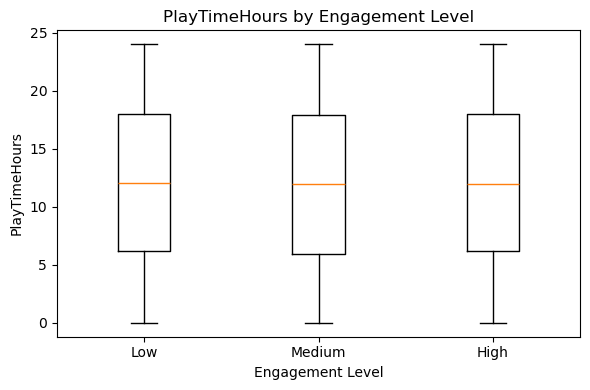

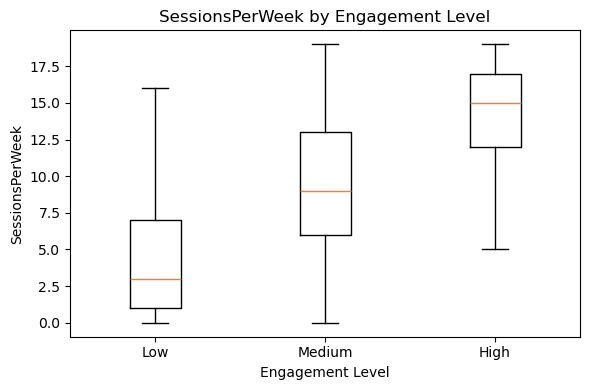

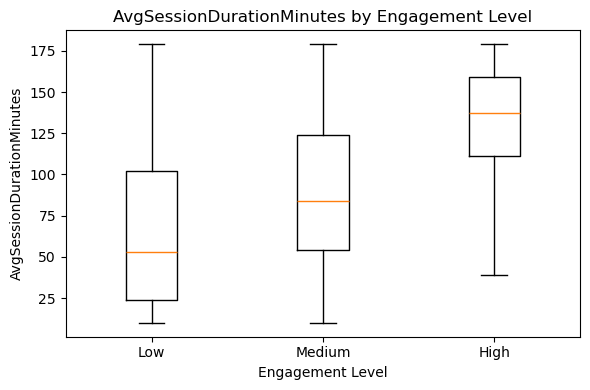

In [81]:
# 3.3 Numeric features: boxplots by engagement
def boxplot_by_group(df_in, feature, group_col="EngagementLevel"):
    groups = ["Low", "Medium", "High"]
    data = [df_in.loc[df_in[group_col] == g, feature].dropna() for g in groups]

    plt.figure(figsize=(6, 4))
    plt.boxplot(data, tick_labels=groups, showfliers=False)
    plt.title(f"{feature} by Engagement Level")
    plt.xlabel("Engagement Level")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

for f in ["PlayTimeHours", "SessionsPerWeek", "AvgSessionDurationMinutes"]:
    if f in df_eda.columns:
        boxplot_by_group(df_eda, f)

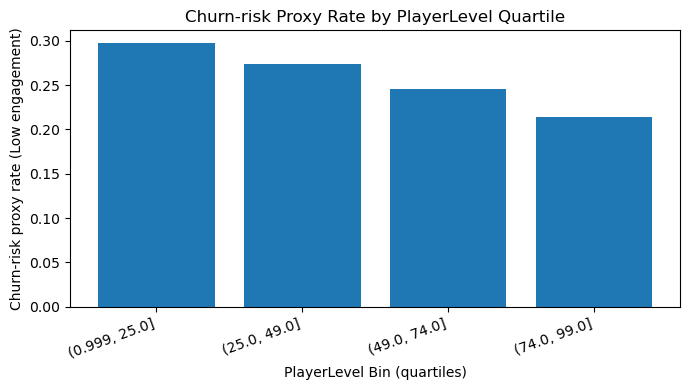

EarlyStage
Not early-stage    0.244299
Early-stage        0.297069
Name: y, dtype: float64

In [ ]:
# 4. Early-stage behaviour vs churn-risk proxy
# Create churn proxy
tmp = df.copy()
tmp["y"] = (tmp["EngagementLevel"].astype(str).str.lower().str.strip() == "low").astype(int)

# Bin PlayerLevel
tmp["PlayerLevel_bin"] = pd.qcut(tmp["PlayerLevel"], q=4, duplicates="drop")
level_churn = tmp.groupby("PlayerLevel_bin")["y"].mean().sort_values(ascending=False)

plt.figure(figsize=(7,4))
plt.bar(level_churn.index.astype(str), level_churn.values)
plt.title("Churn-risk Proxy Rate by PlayerLevel Quartile")
plt.xlabel("PlayerLevel Bin (quartiles)")
plt.ylabel("Churn-risk proxy rate (Low engagement)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

early_cut = tmp["PlayerLevel"].quantile(0.25)  # bottom 25% as early-stage
tmp["EarlyStage"] = (tmp["PlayerLevel"] <= early_cut).astype(int)

early_rate = tmp.groupby("EarlyStage")["y"].mean()
early_rate.rename(index={0: "Not early-stage", 1: "Early-stage"})

**Observation:**  
Churn-risk proxy rates are higher among players in the lowest PlayerLevel bins and decrease as PlayerLevel increases.

**Interpretation:**  
Disengagement often occur early in the player lifecycle.

              churn_rate  avg_playtime  count
SpenderGroup                                 
High-spender    0.253327     11.940694   8041
Non-payer       0.259025     12.045395  31993


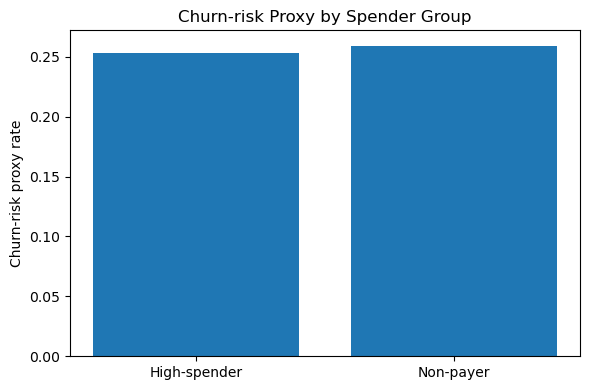

In [83]:
# 5. High spender patterns
# Create payer flag
tmp = df.copy()
tmp["y"] = (tmp["EngagementLevel"] == "Low").astype(int)

tmp["IsPayer"] = (tmp["InGamePurchases"] > 0).astype(int)

# Define high spenders as top 10% among payers
payer_threshold = tmp.loc[tmp["IsPayer"] == 1, "InGamePurchases"].quantile(0.9)

tmp["SpenderGroup"] = "Non-payer"
tmp.loc[tmp["IsPayer"] == 1, "SpenderGroup"] = "Payer"
tmp.loc[tmp["InGamePurchases"] >= payer_threshold, "SpenderGroup"] = "High-spender"

tmp["SpenderGroup"].value_counts()

# Churn-risk comparison table
spender_summary = (
    tmp.groupby("SpenderGroup")
       .agg(
           churn_rate=("y", "mean"),
           avg_playtime=("PlayTimeHours", "mean"),
           count=("y", "size")
       )
)

print(spender_summary)

plt.figure(figsize=(6,4))
plt.bar(spender_summary.index, spender_summary["churn_rate"])
plt.ylabel("Churn-risk proxy rate")
plt.title("Churn-risk Proxy by Spender Group")
plt.tight_layout()
plt.show()

**Observation:**  
High-spenders show lower churn-risk proxy rates compared to non-payers and regular payers.

**Interpretation:**  
Monetisation is associated with stronger retention, yet spending alone does not fully explain disengagement behaviour.

In [ ]:
# 6. Compare distributions across GameGenre
# Engagement distribution within each genre (stack proportions)

genre_eng = pd.crosstab(df_eda["GameGenre"], df_eda["EngagementLevel"],normalize="index")
genre_eng =  genre_eng[["Low", "Medium", "High"]].sort_values("Low", ascending=False)
genre_eng.head(10)

EngagementLevel,Low,Medium,High
GameGenre,,,
RPG,0.263707,0.486293,0.250000
Simulation,0.261556,0.474884,0.263560
Sports,0.257704,0.483474,0.258822
Action,0.256126,0.487125,0.256748
Strategy,0.250374,0.487893,0.261732


**Observation:**  
Churn-risk proxy rates vary only slightly across game genres.

**Interpretation:**  
This indicates that genre alone is not a strong marginal driver of disengagement in this dataset.  
Behavioural intensity features are likely to play a more important role in predicting churn-risk.